# Resumable, Indexed Dataloading

This notebook demonstrates Lhotse's indexed dataloading features for **O(1) random-access**, **shuffled iteration**, and **checkpoint/restore** of the full dataloading pipeline.

We use mini LibriSpeech throughout and build up from basic indexed access to a full training pipeline with mid-epoch resumption.

Key concepts covered:
- Uncompressed `.jsonl` files with binary `.idx` indexes for O(1) access
- `CutSet.from_file(path, indexed=True)` — the recommended way to load indexed CutSets
- `CutSet.from_file(path, shuffle=True, seed=42)` — seed-based shuffled iteration
- `CutSet.state_dict()` / `load_state_dict()` — checkpoint/restore mid-epoch
- Lhotse Shar with indexes — `to_shar(compress_jsonl=False, create_index=True)`
- Full training pipeline with `DynamicBucketingSampler` + `IterableDatasetWrapper`
- (Optional) `torchdata.StatefulDataLoader` integration

In [1]:
# Get the latest version of Lhotse, if not installed:
#!pip install git+https://github.com/lhotse-speech/lhotse

In [2]:
import os
from pathlib import Path

from lhotse import CutSet, Fbank
from lhotse.recipes import download_librispeech, prepare_librispeech

/Users/pzelasko/miniforge3/envs/lhotse5/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
root_dir = Path("data")
tmp_dir = Path("tmp")
tmp_dir.mkdir(exist_ok=True)
num_jobs = os.cpu_count() - 1

## 1. Download & Prepare mini LibriSpeech

We download mini LibriSpeech, prepare recording/supervision manifests, compile them into CutSets, and trim to supervision boundaries (one cut per utterance).

Approximate download size: 450 MB.

In [4]:
libri_variant = "mini_librispeech"
libri_root = download_librispeech(root_dir, dataset_parts=libri_variant)
libri = prepare_librispeech(
    libri_root, dataset_parts=libri_variant, output_dir=root_dir, num_jobs=num_jobs
)
cuts_train = CutSet.from_manifests(**libri["train-clean-5"])
print(f"Training cuts: {len(cuts_train)}")

Dataset parts: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 7936.24it/s]

Training cuts: 1519


## 2. Save as Uncompressed JSONL

Indexed access requires **uncompressed** `.jsonl` files (not `.jsonl.gz`).

Why? Because a binary index stores byte-offsets into the file — compression makes those offsets meaningless.

In [5]:
cuts_path = tmp_dir / "mini-libri-train.jsonl"
cuts_train.to_jsonl(cuts_path)
print(f"Saved {len(cuts_train)} cuts to {cuts_path}")
print(f"File size: {cuts_path.stat().st_size:,} bytes")

Saved 1519 cuts to tmp/mini-libri-train.jsonl
File size: 1,079,330 bytes


## 3. Indexed O(1) Access

`CutSet.from_file(path, indexed=True)` loads a CutSet backed by a binary index.
The `.idx` file is auto-created if it doesn't exist yet.

Once indexed, you get:
- `cuts[i]` — O(1) random access by integer index (single seek + read + JSON parse)
- `has_constant_time_access` — a property that tells you whether O(1) access is available

In [6]:
cuts = CutSet.from_file(cuts_path, indexed=True)
print(f"is_lazy: {cuts.is_lazy}")
print(f"has_constant_time_access: {cuts.has_constant_time_access}")

# O(1) random access by integer index
print(f"\ncuts[0]:   {cuts[0].id}")
print(f"cuts[42]:  {cuts[42].id}")
print(f"cuts[-1]:  {cuts[-1].id}")

is_lazy: True
has_constant_time_access: True

cuts[0]:   1737-146161-0000-0
cuts[42]:  4680-16042-0024-42
cuts[-1]:  32-21631-0019-1518


## 4. Shuffled Iteration

`CutSet.from_file(path, shuffle=True, seed=42)` provides seed-based shuffled iteration.

Under the hood it uses a Feistel-cipher permutation — O(1) memory, deterministic, and every element appears exactly once. No need to load the entire file into memory.

In [7]:
cs_shuffled = CutSet.from_file(cuts_path, shuffle=True, seed=42)
shuffled_ids = [c.id for c in cs_shuffled]
original_ids = sorted(c.id for c in cuts_train)

print(f"Shuffled first 5: {shuffled_ids[:5]}")
print(f"All {len(shuffled_ids)} items present: {sorted(shuffled_ids) == original_ids}")

Shuffled first 5: ['1898-145715-0017-1465', '1088-134318-0012-871', '1867-154075-0015-509', '3526-176653-0027-967', '7367-86737-0019-394']
All 1519 items present: True


In [8]:
# Determinism: same seed always produces the same order
cs_a = CutSet.from_file(cuts_path, shuffle=True, seed=42)
cs_b = CutSet.from_file(cuts_path, shuffle=True, seed=42)
assert [c.id for c in cs_a] == [c.id for c in cs_b]
print("Deterministic: same seed produces identical order")

Deterministic: same seed produces identical order


## 5. CutSet Checkpoint / Restore

Lazy CutSets support `state_dict()` / `load_state_dict()` for checkpointing the iteration position mid-epoch.

The core property is:

```
first_k_items + remaining_items == all_items
```

You can stop iteration at any point, save the state, and resume later to get exactly the remaining items — no duplication, no skipping.

In [9]:
# Full uninterrupted run
full_ids = [c.id for c in CutSet.from_file(cuts_path, indexed=True)]
print(f"Full run: {len(full_ids)} items")

# Interrupted run: consume first 500 items, then save checkpoint
n_consumed = 500
cs1 = CutSet.from_file(cuts_path, indexed=True)
gen1 = iter(cs1)
first_k = [next(gen1).id for _ in range(n_consumed)]
sd = cs1.state_dict()
print(f"Consumed {len(first_k)} items, saved state_dict")
print(f"State dict keys: {list(sd.keys())}")

# Restored run: resume from checkpoint
cs2 = CutSet.from_file(cuts_path, indexed=True)
cs2.load_state_dict(sd)
remaining = [c.id for c in cs2]
print(f"Remaining after restore: {len(remaining)} items")

# Verify the fundamental property
assert first_k + remaining == full_ids
print(f"\nfirst_k ({len(first_k)}) + remaining ({len(remaining)}) == full ({len(full_ids)})")

Full run: 1519 items
Consumed 500 items, saved state_dict
State dict keys: ['_type', '_state']
Remaining after restore: 1019 items

first_k (500) + remaining (1019) == full (1519)


## 6. Lhotse Shar with Indexes

When exporting to Shar format, set `compress_jsonl=False` and `create_index=True` to produce uncompressed JSONL manifests with binary indexes alongside the tar archives.

This enables **O(1) random access** and **checkpoint/restore** for Shar-based dataloading.

In [10]:
shar_dir = tmp_dir / "shar-indexed"
shar_dir.mkdir(exist_ok=True)

shards = cuts_train.to_shar(
    output_dir=shar_dir,
    fields={"recording": "wav"},
    shard_size=1000,
    compress_jsonl=False,
    create_index=True,
)
shards

{'cuts': ['tmp/shar-indexed/cuts.000000.jsonl',
  'tmp/shar-indexed/cuts.000001.jsonl'],
 'recording': ['tmp/shar-indexed/recording.000000.tar',
  'tmp/shar-indexed/recording.000001.tar']}

In [11]:
!tree {shar_dir}

tmp/shar-indexed
├── cuts.000000.jsonl
├── cuts.000000.jsonl.idx
├── cuts.000001.jsonl
├── cuts.000001.jsonl.idx
├── recording.000000.tar
├── recording.000000.tar.idx
├── recording.000001.tar
└── recording.000001.tar.idx

1 directory, 8 files


In [12]:
# Read back from Shar — .idx files are auto-detected
shar_cuts = CutSet.from_shar(in_dir=shar_dir)
print(f"has_constant_time_access: {shar_cuts.data.has_constant_time_access}")

# O(1) random access works on Shar too
print(f"\nshar_cuts[0]:   {shar_cuts.data[0].id}")
print(f"shar_cuts[42]:  {shar_cuts.data[42].id}")
print(f"shar_cuts[-1]:  {shar_cuts.data[-1].id}")

has_constant_time_access: True

shar_cuts[0]:   1737-146161-0000-0
shar_cuts[42]:  4680-16042-0024-42
shar_cuts[-1]:  32-21631-0019-1518


In [13]:
# Verify all IDs match
shar_ids = sorted(c.id for c in CutSet.from_shar(in_dir=shar_dir))
train_ids = sorted(c.id for c in cuts_train)
assert shar_ids == train_ids
print(f"Read {len(shar_ids)} cuts from Shar — IDs match original")

Read 1519 cuts from Shar — IDs match original


## 7. Full Training Pipeline

Here we build a real training pipeline:
- Load a single-file CutSet via `from_file(indexed=True)`
- Batch with `DynamicBucketingSampler`
- Compute features on-the-fly with `K2SpeechRecognitionDataset(OnTheFlyFeatures(Fbank()))`
- Use `num_workers=2` for parallel data loading
- Checkpoint mid-epoch and resume
- Visualize a real batch

In [14]:
import torch.utils.data
from torch.utils.data import DataLoader

from lhotse.dataset import (
    DynamicBucketingSampler,
    K2SpeechRecognitionDataset,
    OnTheFlyFeatures,
)
from lhotse.dataset.iterable_dataset import IterableDatasetWrapper
from lhotse.dataset.vis import plot_batch

In [15]:
def make_pipeline():
    """Build a fresh pipeline — required for clean checkpoint/restore."""
    cs = CutSet.from_file(cuts_path, indexed=True)
    sampler = DynamicBucketingSampler(
        cs, max_duration=100.0, shuffle=False, seed=0, num_buckets=5
    )
    dataset = K2SpeechRecognitionDataset(
        input_strategy=OnTheFlyFeatures(Fbank()),
    )
    return IterableDatasetWrapper(dataset=dataset, sampler=sampler)

Checkpointed after step 4
State dict top-level keys: ['epoch', 'sampler_state']


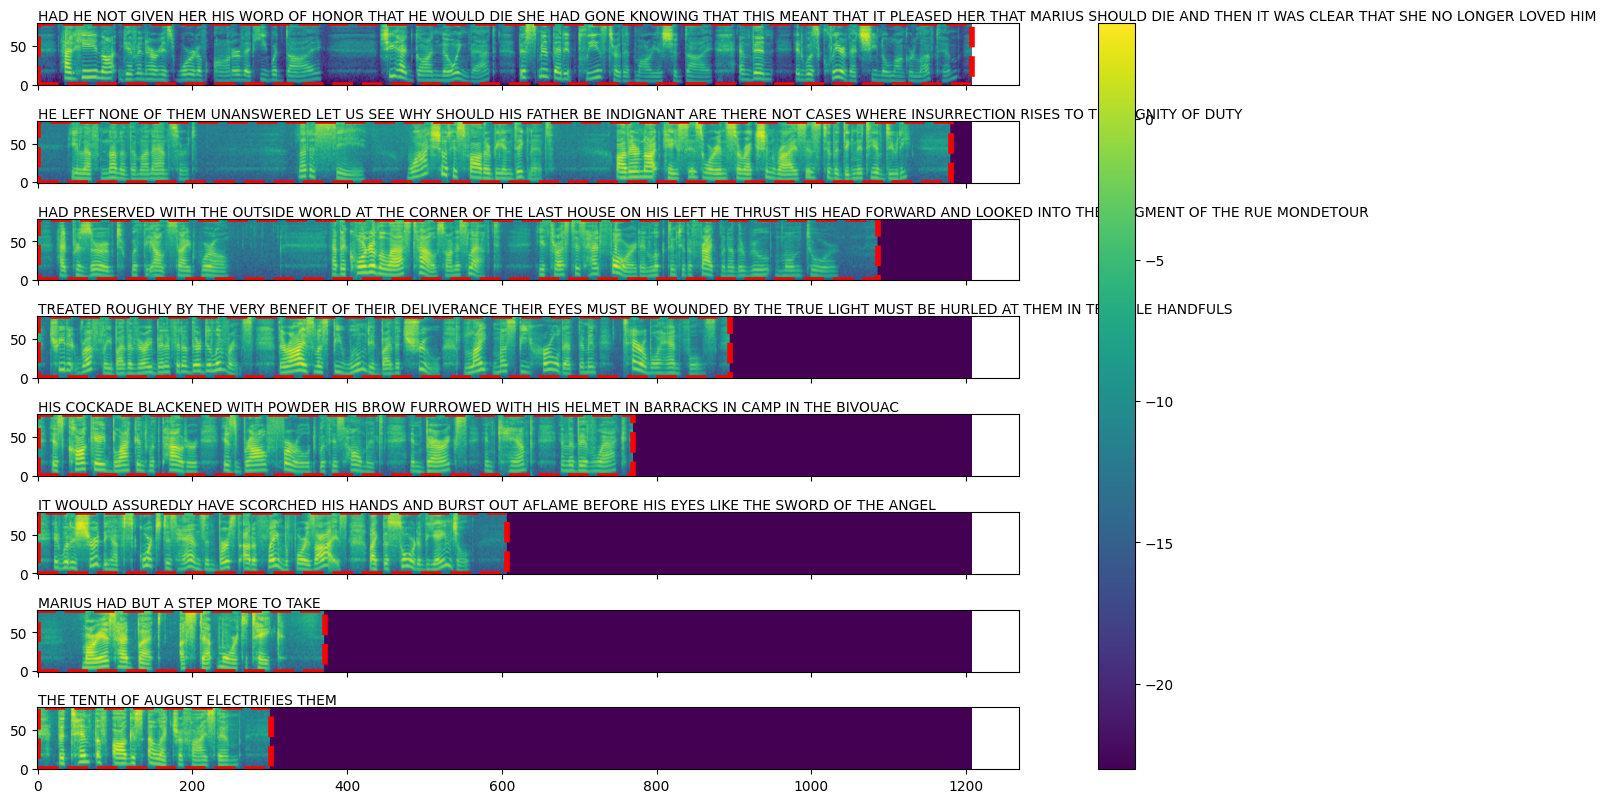

In [16]:
# Train for a few steps, visualize a batch, then checkpoint
wrapper = make_pipeline()
dloader = DataLoader(wrapper, batch_size=None, num_workers=2)

batches = []
for step, batch in enumerate(dloader):
    batches.append(batch)
    if step == 4:
        sd = wrapper.state_dict()
        print(f"Checkpointed after step {step}")
        print(f"State dict top-level keys: {list(sd.keys())}")
        break

# Visualize the last batch
plot_batch(batches[-1])

Resumed! First batch after restore has 6 utterances


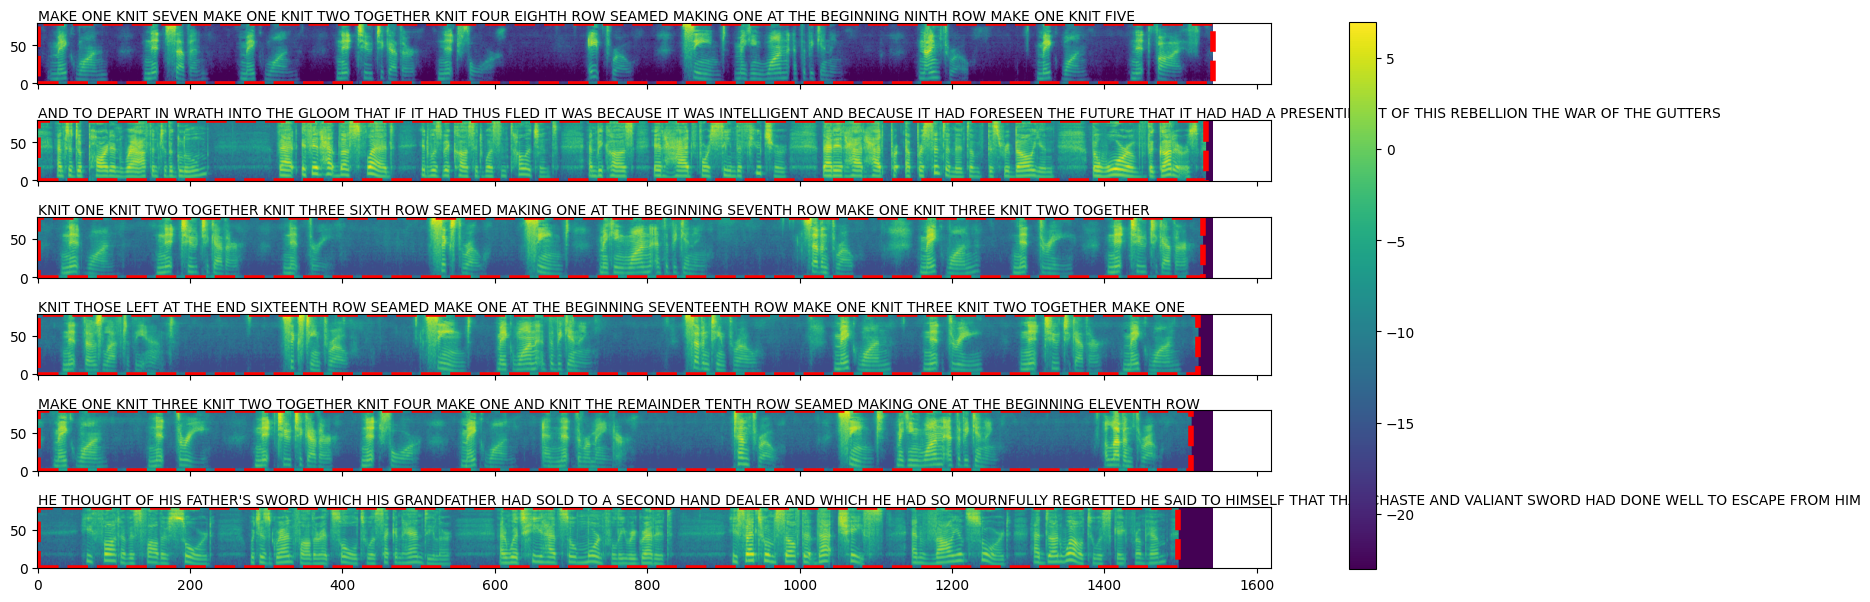

In [17]:
# Resume: create a fresh pipeline and load the checkpoint
wrapper2 = make_pipeline()
wrapper2.load_state_dict(sd)
dloader2 = DataLoader(wrapper2, batch_size=None, num_workers=2)

for step, batch in enumerate(dloader2):
    if step == 0:
        print(f"Resumed! First batch after restore has {batch['inputs'].shape[0]} utterances")
        plot_batch(batch)
        break

## 8. StatefulDataLoader (torchdata)

If `torchdata` is installed, `StatefulDataLoader` is a drop-in replacement for `DataLoader` that natively supports `state_dict()` / `load_state_dict()` with multi-worker support.

Lhotse's `IterableDatasetWrapper` integrates seamlessly — the state of each worker is captured and restored independently.

In [18]:
try:
    from torchdata.stateful_dataloader import StatefulDataLoader
    HAS_TORCHDATA = True
except ImportError:
    HAS_TORCHDATA = False
    print("torchdata not installed — skipping this section.")
    print("Install with: pip install torchdata")

In [19]:
from lhotse.dataset import IdentityDataset


def make_simple_pipeline():
    cs = CutSet.from_file(cuts_path, indexed=True)
    sampler = DynamicBucketingSampler(
        cs, max_duration=100.0, shuffle=False, seed=0, num_buckets=5
    )
    return IterableDatasetWrapper(IdentityDataset(), sampler)

In [20]:
if HAS_TORCHDATA:
    # Full run
    dl_full = StatefulDataLoader(make_simple_pipeline(), batch_size=None, num_workers=2)
    all_batches = [[c.id for c in b] for b in dl_full]
    print(f"Total batches: {len(all_batches)}")

    # Interrupted run: consume 5 batches
    n_consumed = 5
    dl1 = StatefulDataLoader(make_simple_pipeline(), batch_size=None, num_workers=2)
    it1 = iter(dl1)
    first_k = [[c.id for c in next(it1)] for _ in range(n_consumed)]
    sd = dl1.state_dict()
    print(f"Consumed {n_consumed} batches")

    # Restored run
    dl2 = StatefulDataLoader(make_simple_pipeline(), batch_size=None, num_workers=2)
    dl2.load_state_dict(sd)
    remaining = [[c.id for c in b] for b in dl2]

    assert first_k + remaining == all_batches
    print(f"StatefulDataLoader: {len(first_k)} + {len(remaining)} = {len(all_batches)} batches")
else:
    print("Skipped (torchdata not available)")

Total batches: 456
Consumed 5 batches
StatefulDataLoader: 5 + 451 = 456 batches


## 9. Summary

| Feature | API |
|---------|-----|
| Load indexed CutSet | `CutSet.from_file(path, indexed=True)` |
| O(1) random access | `cuts[idx]` |
| Check O(1) support | `cuts.has_constant_time_access` |
| Shuffled iteration | `CutSet.from_file(path, shuffle=True, seed=42)` |
| CutSet checkpoint | `sd = cuts.state_dict()` |
| CutSet restore | `cuts.load_state_dict(sd)` |
| Shar with indexes | `cuts.to_shar(..., compress_jsonl=False, create_index=True)` |
| Shar random access | `CutSet.from_shar(in_dir=...)` then `cuts.data[idx]` |
| Full pipeline checkpoint | `IterableDatasetWrapper.state_dict()` / `load_state_dict()` |
| StatefulDataLoader | `torchdata.StatefulDataLoader` (drop-in replacement) |

In [21]:
# Cleanup (optional)
import shutil
shutil.rmtree(shar_dir, ignore_errors=True)